Bug test the re-formatted protint code, with the new anndata object where only tissues with at least 20 samples in both datasets are kept.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import scanpy as sc
import matplotlib.pyplot as plt
from protint.projection import decode_matrix, load_model
from protint.model_cvae import BatchCVAEFeatureWiseDropout
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
import yaml
with open("../../config/config.local.yaml", "r") as f:
    config = yaml.safe_load(f)
basedir = config['code_dir']

input_dir = os.path.join(config['output_data_dir'], 
                         "processed_proteomics_data",
                         "1_1_9_ProCan_FDL_PanCancer_merged_tissue20.h5ad"
)  # where the tumor and cell line data, in anndata format, are stored

data_output_dir = os.path.join(config['output_data_dir'], "protint_output")  # where the output of the protint model will be stored
if not os.path.exists(data_output_dir):
    os.makedirs(data_output_dir)

In [3]:
%reload_ext autoreload
%autoreload 2
from Utils.helper_functions import reconstruct_with_original_batch
from Utils.plot_functions import plot_training_loss, joint_umap_original_reconstructed, plot_detected_reconstructed_imputed_histogram
from Utils.color_palette import tissue_palette

## Plotting initial data

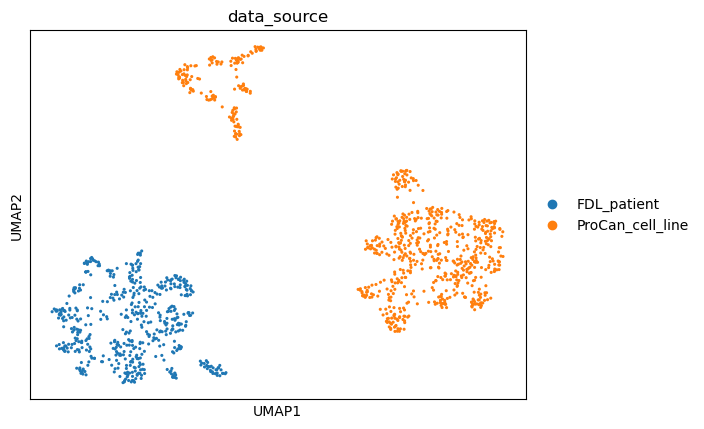

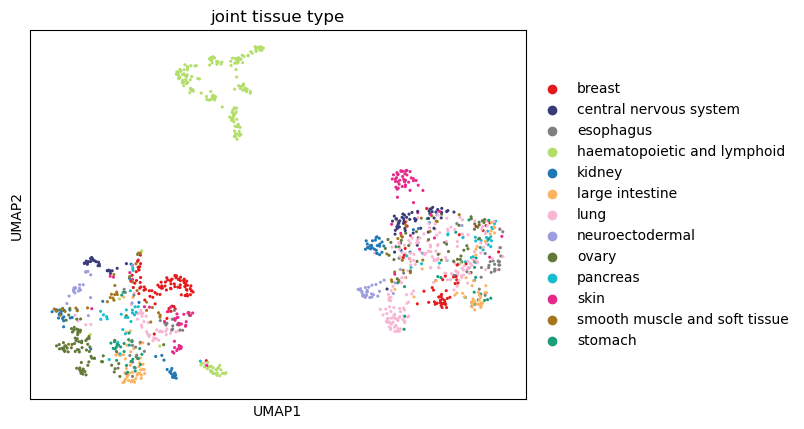

In [6]:
adata = sc.read_h5ad(input_dir)
# quick umap of the adata
# Use the imputed layer as the working matrix
sc.pp.pca(adata, n_comps=50, mask_var=None)

# Build neighbor graph from the PCA representation computed above
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50, use_rep="X_pca")

# UMAP with your settings
sc.tl.umap(adata, min_dist=0.5)

# (Optional) quick plot
sc.pl.umap(adata, color="data_source", size=20)
sc.pl.umap(adata, color="joint tissue type", size=20, palette=tissue_palette)

## Testing ProtInt with no contribution from dropout

In [9]:
cmd = [
    "protint", "train",
    "--train_file", input_dir,
    "--hidden_dims", "128 64",
    "--encoding_dim", "32",
    "--batch_size", "512",
    "--epochs", "3000",
    "--batch_lr", "1e-3",
    "--src_adv_lr", "1e-3",
    "--kl_weight", "1e-6",
    "--dropout_weight", "0.1",
    "--src_adv_weight", "100",
    "--cyc_weight", "0",
    "--output_dir", data_output_dir,
    "--random_seed", "15"
]

result = subprocess.run(cmd, check=False)

print("Return code:", result.returncode)

Using device: cuda
Return code: 0


⚠️ Warning: Cycle Consistency file not found: /local-home/tacongqu/projects/cellLine_patient_project/02_processedData/protint_output/metrics/NA


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Training Loss (log scale)'}, xlabel='Epoch', ylabel='Loss'>)

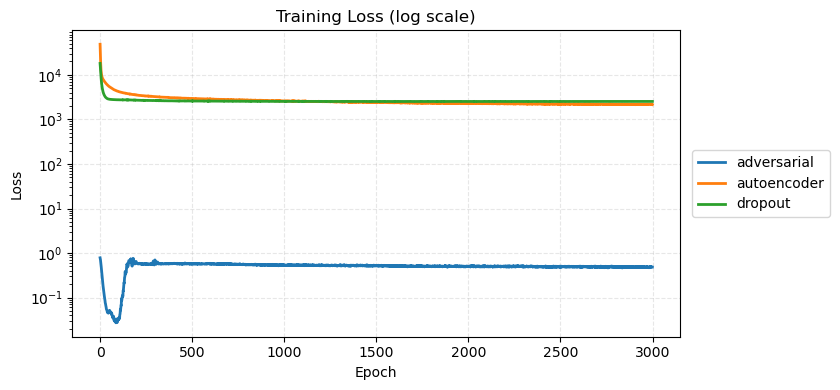

In [14]:
plot_training_loss(data_output_dir, ae_file="train_loss_rec", cyc_file="NA", hline=None)  # cycle consistency is not used in this run, so we can leave the cyc_file empty

In [5]:
cmd = [
    "protint", "projection",
    "--projection_file", input_dir,
    "--model_dir", os.path.join(data_output_dir, "models"),
    "--onto", "FDL_patient",
    "--output_file", os.path.join(data_output_dir, "projection.h5ad"),
]

result = subprocess.run(cmd, check=False)

print("Return code:", result.returncode)

/share/conda-envs/cellLine_patient/lib/python3.11/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Loaded model epoch: 2999, loss 2366.096091975776
Return code: 0


In [16]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, features, label_encode = load_model(
    os.path.join(data_output_dir, "models"),
    device,
    model_cls=BatchCVAEFeatureWiseDropout,
)
# Important: same feature order as training/model
adata = adata[:, features].copy()

recon_adata, z_adata = reconstruct_with_original_batch(
    model=model,
    adata=adata,
    label_encode=label_encode,
    decode_matrix=decode_matrix,
    batch_key="data_source",   # replace with your adata.obs column
    device=device,
    decimals=4,
    batch_size=1600,
)

Loaded model epoch: 2999, loss 2366.096091975776


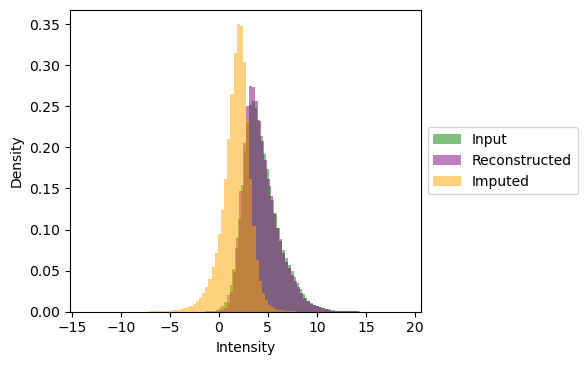

In [17]:
plot_detected_reconstructed_imputed_histogram(
    adata,
    recon_adata,
    figsize=(6,3.75))

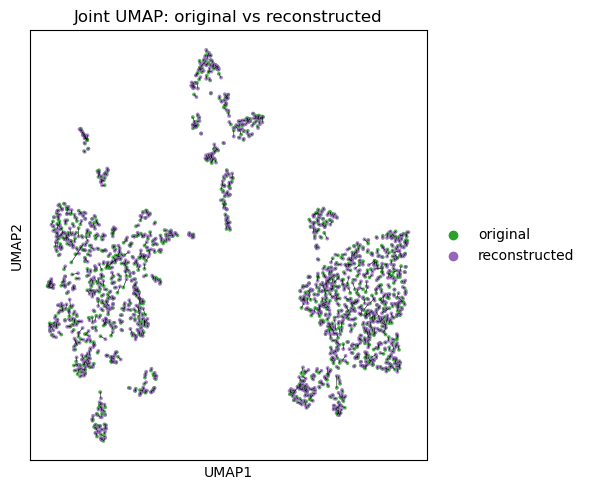

In [18]:
joint, fig, ax = joint_umap_original_reconstructed(
    adata,
    recon_adata,
    detected_layer="detected",
    figsize=(6,5),
    size=30
)

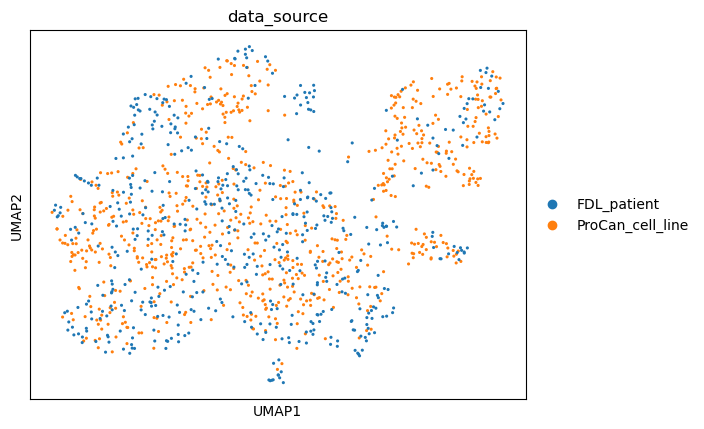

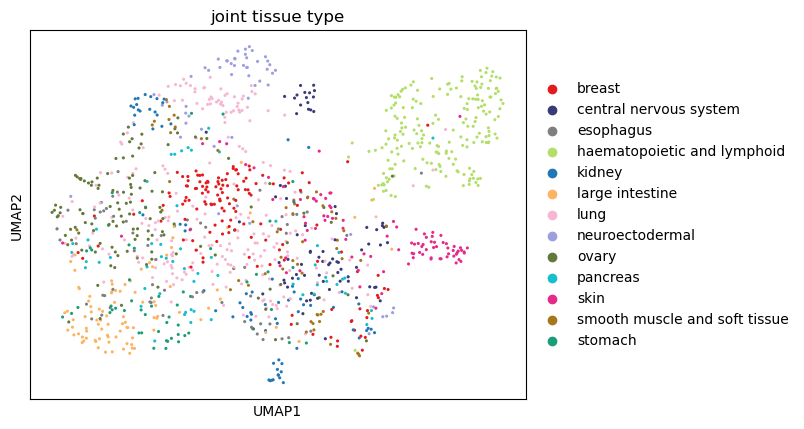

In [7]:

# import the projected data and visualize
adata_projected = sc.read_h5ad(os.path.join(data_output_dir, "projection.h5ad"))

# Copy harmonized color palette
adata_projected.uns["joint tissue type_colors"] = adata.uns["joint tissue type_colors"].copy()
# quick umap of the adata
# Use the imputed layer as the working matrix
sc.pp.pca(adata_projected, n_comps=50, mask_var=None)

# Build neighbor graph from the PCA representation computed above
sc.pp.neighbors(adata_projected, n_neighbors=15, n_pcs=50, use_rep="X_pca")

# UMAP with your settings
sc.tl.umap(adata_projected, min_dist=0.5)

# (Optional) quick plot
sc.pl.umap(adata_projected, color="data_source", size=20)
sc.pl.umap(adata_projected, color="joint tissue type", size=20, palette=tissue_palette)

## Classifying patients by cell lines

In [9]:
def classify_patients_by_nearest_celllines(
    proj_adata,
    source_col="data_source",
    tissue_col="joint tissue type",
    patient_label="FDL_patient",
    cellline_label="ProCan_cell_line",
    n_neighbors=5,
    pca_key="X_pca",
    return_neighbor_table=False,
):
    # --- checks ---
    if pca_key not in proj_adata.obsm:
        raise KeyError(f"{pca_key!r} not found in proj_adata.obsm. Run PCA first.")
    if source_col not in proj_adata.obs:
        raise KeyError(f"{source_col!r} not found in proj_adata.obs.")
    if tissue_col not in proj_adata.obs:
        raise KeyError(f"{tissue_col!r} not found in proj_adata.obs.")

    obs = proj_adata.obs.copy()
    X_pca = proj_adata.obsm[pca_key]

    patient_mask = obs[source_col].eq(patient_label).values
    cellline_mask = obs[source_col].eq(cellline_label).values

    if patient_mask.sum() == 0:
        raise ValueError(f"No rows found with {source_col} == {patient_label!r}.")
    if cellline_mask.sum() == 0:
        raise ValueError(f"No rows found with {source_col} == {cellline_label!r}.")

    X_patient = X_pca[patient_mask]
    X_cellline = X_pca[cellline_mask]

    patient_obs = obs.loc[patient_mask].copy()
    cellline_obs = obs.loc[cellline_mask].copy()

    cellline_tissues = cellline_obs[tissue_col].astype(str).values
    patient_true = patient_obs[tissue_col].astype(str).values

    k = min(n_neighbors, X_cellline.shape[0])
    if k < n_neighbors:
        print(f"Warning: only {k} cell lines available, using k={k}.")

    # --- nearest cell-line search ---
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(X_cellline)
    distances, indices = nn.kneighbors(X_patient)

    # --- majority-vote prediction ---
    pred_labels = []
    pred_counts = []
    top_neighbor_tissues = []

    for idx_row in indices:
        neighbor_tissues = cellline_tissues[idx_row]
        counts = Counter(neighbor_tissues)
        most_common = counts.most_common()

        max_count = most_common[0][1]
        tied = sorted([label for label, c in most_common if c == max_count])
        pred_label = tied[0]  # deterministic tie-break

        pred_labels.append(pred_label)
        pred_counts.append(max_count)
        top_neighbor_tissues.append(list(neighbor_tissues))

    results = patient_obs[[tissue_col]].copy()
    results = results.rename(columns={tissue_col: "true_tissue"})
    results["pred_tissue"] = pred_labels
    results["vote_count"] = pred_counts
    results["correct"] = results["true_tissue"] == results["pred_tissue"]

    # optional: attach patient IDs/names if available
    results["patient_obs_name"] = patient_obs.index

    accuracy = accuracy_score(results["true_tissue"], results["pred_tissue"])

    labels = sorted(
        set(results["true_tissue"].astype(str)).union(set(results["pred_tissue"].astype(str)))
    )
    cm = confusion_matrix(
        results["true_tissue"],
        results["pred_tissue"],
        labels=labels,
    )
    cm_df = pd.DataFrame(
        cm,
        index=pd.Index(labels, name="true_tissue"),
        columns=pd.Index(labels, name="pred_tissue"),
    )

    out = {
        "results": results,
        "confusion_matrix": cm_df,
        "accuracy": accuracy,
    }

    if return_neighbor_table:
        neighbor_table = pd.DataFrame(
            {
                "patient_obs_name": patient_obs.index,
                "true_tissue": patient_true,
                "neighbor_tissues": top_neighbor_tissues,
                "neighbor_distances": [list(x) for x in distances],
            }
        )
        out["neighbor_table"] = neighbor_table

    return out

In [10]:
out = classify_patients_by_nearest_celllines(
    adata_projected,
    source_col="data_source",
    tissue_col="joint tissue type",
    patient_label="FDL_patient",
    cellline_label="ProCan_cell_line",
    n_neighbors=5,
    return_neighbor_table=True,
)

print(f"Accuracy: {out['accuracy']:.3f}")
display(out["confusion_matrix"])
display(out["results"].head())

Accuracy: 0.382


pred_tissue,breast,central nervous system,esophagus,haematopoietic and lymphoid,kidney,large intestine,lung,neuroectodermal,ovary,pancreas,skin,smooth muscle and soft tissue,stomach
true_tissue,,,,,,,,,,,,,
breast,49,9,1,5,7,0,18,0,1,0,0,0,0
central nervous system,0,1,0,2,0,0,12,7,0,0,3,0,0
esophagus,1,2,3,1,9,2,12,0,0,0,0,1,0
haematopoietic and lymphoid,0,1,0,30,0,0,0,0,0,0,0,0,0
kidney,0,1,0,0,14,0,19,7,0,0,1,2,0
large intestine,1,1,0,2,4,39,1,0,0,0,0,1,0
lung,0,4,0,4,5,0,27,0,0,0,0,0,0
neuroectodermal,1,3,0,0,2,0,1,16,0,0,0,0,0
ovary,2,3,22,1,1,5,41,1,5,1,0,3,1


,true_tissue,pred_tissue,vote_count,correct,patient_obs_name
cell_id,,,,,
00FZN,central nervous system,neuroectodermal,3,False,00FZN
00FZL,central nervous system,skin,3,False,00FZL
00FZJ,central nervous system,haematopoietic and lymphoid,2,False,00FZJ
00FZ1,central nervous system,lung,3,False,00FZ1
00FYV,central nervous system,neuroectodermal,3,False,00FYV


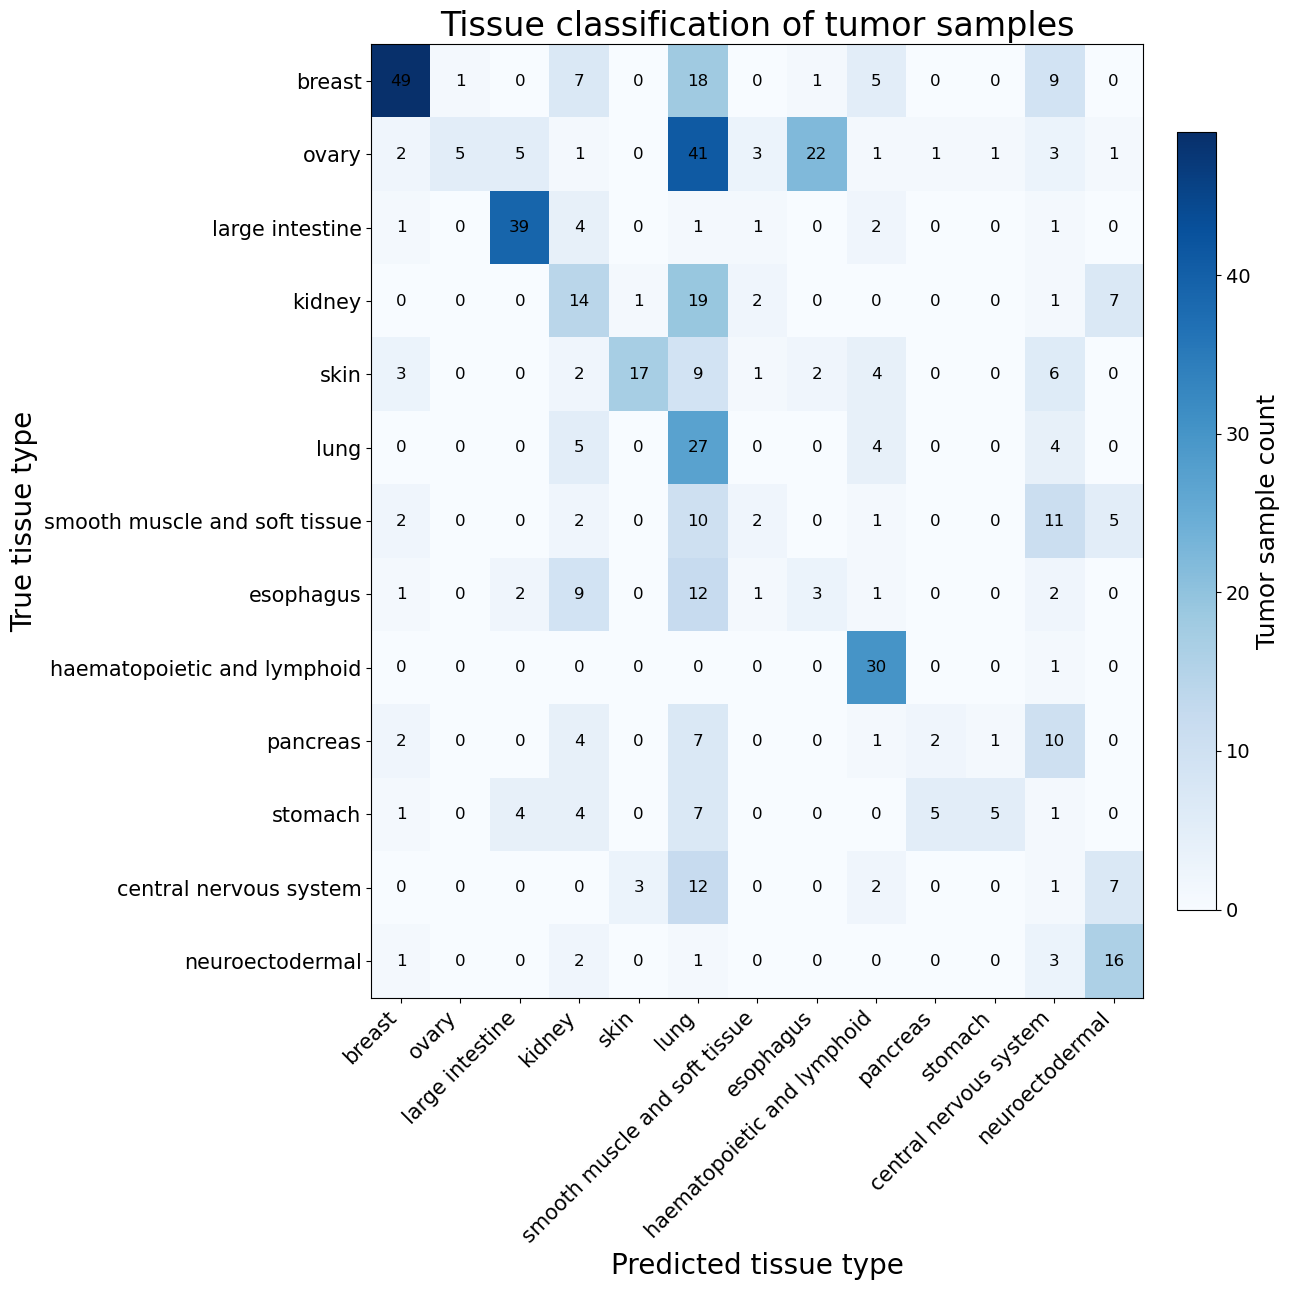

In [11]:
cm_df = out["confusion_matrix"]

# Sort rows by total true count, highest first
common_order = cm_df.sum(axis=1).sort_values(ascending=False).index
cm_plot = cm_df.loc[common_order, common_order]

fig, ax = plt.subplots(figsize=(13, 13))

im = ax.imshow(
    cm_plot.values,
    cmap="Blues",
    vmin=0,
    vmax=cm_plot.values.max(),
    aspect="auto",
)

ax.set_xticks(np.arange(len(cm_plot.columns)))
ax.set_xticklabels(cm_plot.columns, rotation=45, ha="right", fontsize=15)
ax.set_yticks(np.arange(len(cm_plot.index)))
ax.set_yticklabels(cm_plot.index, fontsize=15)

ax.set_xlabel("Predicted tissue type", fontsize=20)
ax.set_ylabel("True tissue type", fontsize=20)
ax.set_title(
    f"Tissue classification of tumor samples",
    fontsize=24,
)

# Keep heatmap numbers at the original size
for i in range(cm_plot.shape[0]):
    for j in range(cm_plot.shape[1]):
        ax.text(j, i, cm_plot.iat[i, j], ha="center", va="center", fontsize=12)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Tumor sample count", fontsize=18)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

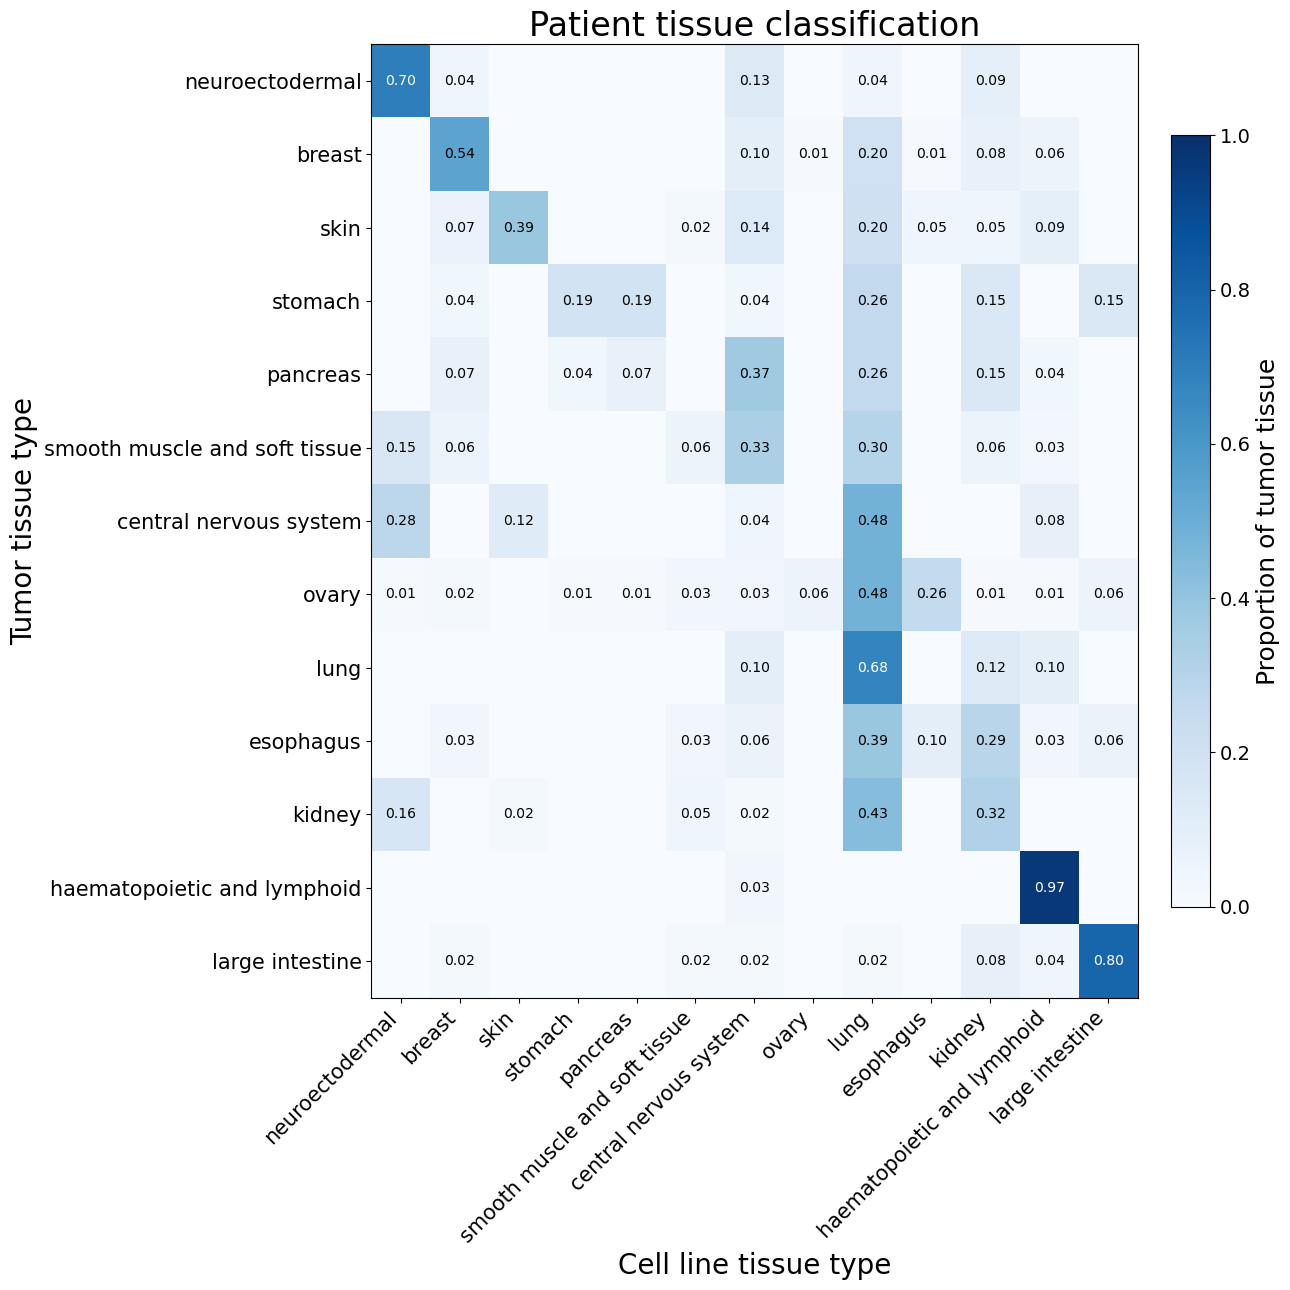

In [12]:
# normalize the confusion matrix by row to get proportions
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

cm_df = out["confusion_matrix"]

# Ensure rows and columns use the same tissue set/order where possible
all_tissues = cm_df.index.union(cm_df.columns)
cm_df = cm_df.reindex(index=all_tissues, columns=all_tissues, fill_value=0)

# Row-normalized confusion matrix:
# each row = true tissue, values = proportion predicted as each tissue
cm_prop = cm_df.div(cm_df.sum(axis=1), axis=0).fillna(0)

# Cluster tissues based on prediction profiles
# correlation distance groups tissues with similar misclassification patterns
dist = pdist(cm_prop.values, metric="correlation")

# If correlation distance fails due to constant rows, fall back to euclidean
if not np.all(np.isfinite(dist)):
    dist = pdist(cm_prop.values, metric="euclidean")

link = linkage(dist, method="average")
cluster_order = cm_prop.index[leaves_list(link)]

# Apply same order to rows and columns to preserve true/predicted tissue alignment
cm_plot = cm_prop.loc[cluster_order, cluster_order]
cm_counts_plot = cm_df.loc[cluster_order, cluster_order]

fig, ax = plt.subplots(figsize=(13, 13))

im = ax.imshow(
    cm_plot.values,
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(np.arange(len(cm_plot.columns)))
ax.set_xticklabels(cm_plot.columns, rotation=45, ha="right", fontsize=15)

ax.set_yticks(np.arange(len(cm_plot.index)))
ax.set_yticklabels(cm_plot.index, fontsize=15)

ax.set_xlabel("Cell line tissue type", fontsize=20)
ax.set_ylabel("Tumor tissue type", fontsize=20)
ax.set_title("Patient tissue classification", fontsize=24)

# Annotate with percentage
for i in range(cm_plot.shape[0]):
    for j in range(cm_plot.shape[1]):
        val = cm_plot.iat[i, j]
        if val > 0:
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black" if val < 0.6 else "white",
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proportion of tumor tissue", fontsize=18)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()